# Machine Learning Classification

A simple classification project done step by step:
1. Data Understanding
2. Baseline Model
3. Advanced Model (better preprocessing + feature engineering)
4. Threshold Tuning
5. Final Comparison (Baseline vs Advanced)

In [473]:
# Import Libraries and Load the dataset
import pandas as pd
import numpy as np

df = pd.read_csv("Student_Productivity_Dataset.csv")
print("Shape:", df.shape)

Shape: (10000, 20)


In [474]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   str    
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motivation_Level

In [475]:
df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


In [476]:
df.tail()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
9995,9996,23.0,Female,4.2,5.5,5.2,1.6,95.5,100.0,6.6,5.0,7.7,8.5,Average,No,9.0,6.3,6.51,80.59,High
9996,9997,24.0,Male,7.1,6.7,4.0,3.2,64.3,74.5,4.0,0.5,6.8,9.4,Good,Yes,7.0,7.1,6.97,62.95,Medium
9997,9998,24.0,Male,6.4,4.4,6.7,3.3,74.1,100.0,10.0,4.5,5.4,1.0,Average,No,0.0,8.2,1.80,43.79,Low
9998,9999,19.0,Male,8.1,6.8,3.5,4.1,59.5,85.9,7.2,4.6,5.0,5.8,Poor,Yes,4.1,3.5,5.24,49.48,Medium
9999,10000,18.0,Male,4.6,7.2,6.8,3.1,66.0,32.1,7.4,2.3,6.4,9.2,Good,No,7.2,4.0,5.54,62.81,Medium


In [477]:
print(df.columns.tolist())
# print bn yozsak gorizantal - printsiz yozsak vertikal chiqarib beradi

df.dtypes

['Student_ID', 'Age', 'Gender', 'Study_Hours_Per_Day', 'Sleep_Hours_Per_Night', 'Screen_Time_Hours', 'Social_Media_Hours', 'Attendance_Percentage', 'Assignments_Completed', 'Class_Participation_Score', 'Physical_Activity_Hours_Per_Week', 'Stress_Level', 'Motivation_Level', 'Internet_Quality', 'Part_Time_Job', 'Extracurricular_Involvement', 'AI_Tool_Usage_Hours_Per_Week', 'Previous_Semester_GPA', 'Productivity_Score', 'Performance_Category']


Student_ID                            int64
Age                                 float64
Gender                                  str
Study_Hours_Per_Day                 float64
Sleep_Hours_Per_Night               float64
Screen_Time_Hours                   float64
Social_Media_Hours                  float64
Attendance_Percentage               float64
Assignments_Completed               float64
Class_Participation_Score           float64
Physical_Activity_Hours_Per_Week    float64
Stress_Level                        float64
Motivation_Level                    float64
Internet_Quality                        str
Part_Time_Job                           str
Extracurricular_Involvement         float64
AI_Tool_Usage_Hours_Per_Week        float64
Previous_Semester_GPA               float64
Productivity_Score                  float64
Performance_Category                    str
dtype: object

In [478]:
df.describe()

,Student_ID,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score
count,10000.00000,9845.000000,9835.000000,9894.000000,9868.000000,9920.000000,9878.000000,9882.000000,9815.000000,9863.000000,9846.000000,9825.000000,9822.000000,9860.000000,9839.000000,10000.000000
mean,5000.50000,20.134891,4.219583,6.976602,6.047862,3.032107,79.817301,74.251872,5.991218,3.200862,5.542840,5.957924,4.050204,5.544726,6.489753,54.607333
std,2886.89568,2.497517,1.950639,1.303614,2.424031,1.729774,12.348369,16.588029,2.150297,2.252450,2.107599,2.111982,2.367947,3.892723,1.580462,12.340640
min,1.00000,16.000000,0.000000,3.000000,1.000000,0.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,18.000000,2.800000,6.100000,4.300000,1.800000,71.200000,62.900000,4.500000,1.600000,4.100000,4.500000,2.300000,2.700000,5.415000,46.640000
50%,5000.50000,20.000000,4.200000,7.000000,6.000000,3.000000,80.200000,74.900000,6.000000,2.700000,5.600000,6.000000,4.000000,4.700000,6.500000,54.935000
75%,7500.25000,22.000000,5.600000,7.900000,7.700000,4.200000,89.100000,86.800000,7.500000,4.300000,7.000000,7.400000,5.700000,7.500000,7.590000,63.032500
max,10000.00000,25.000000,12.000000,10.000000,14.800000,9.700000,100.000000,100.000000,10.000000,15.000000,10.000000,10.000000,10.000000,25.000000,10.000000,100.000000


In [479]:
# Duplicated rows
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [480]:
# Categorical ustunlarning unique qiymatlari
cat_cols = df.select_dtypes(include="str").columns
cat_cols = cat_cols.drop("Student_ID", errors='ignore')

for col in cat_cols:
    print(col, "->", df[col].unique())

Gender -> <StringArray>
['Male', 'Female', nan, 'Other']
Length: 4, dtype: str
Internet_Quality -> <StringArray>
['Poor', 'Good', 'Average', nan]
Length: 4, dtype: str
Part_Time_Job -> <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Performance_Category -> <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str


In [481]:
# Target taqsimoti
df["Performance_Category"].value_counts()

# target biroz imbalanced ekan

Performance_Category
Medium    5000
High      2500
Low       2500
Name: count, dtype: int64

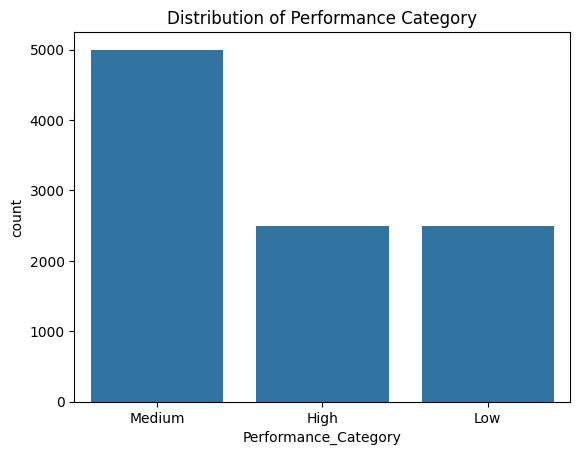

In [482]:
# Targetni grafikda tasvirlash
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Performance_Category")
plt.title("Distribution of Performance Category")
plt.show()

## Baseline Model

In [483]:
df_base = pd.read_csv("Student_Productivity_Dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   str    
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motivation_Level

In [484]:
df_base = df_base.drop(columns=["Student_ID","Productivity_Score"])

In [485]:
df = df_base.copy()

## Preprocessing

In [486]:
df.isnull().sum()

Age                                 155
Gender                              119
Study_Hours_Per_Day                 165
Sleep_Hours_Per_Night               106
Screen_Time_Hours                   132
Social_Media_Hours                   80
Attendance_Percentage               122
Assignments_Completed               118
Class_Participation_Score           185
Physical_Activity_Hours_Per_Week    137
Stress_Level                        154
Motivation_Level                    175
Internet_Quality                    149
Part_Time_Job                       126
Extracurricular_Involvement         178
AI_Tool_Usage_Hours_Per_Week        140
Previous_Semester_GPA               161
Performance_Category                  0
dtype: int64

In [487]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from pandas.api.types import is_numeric_dtype

In [488]:
class DataPreprocessing:
    """
    Ma'lumotlarni tozalash va kodlash uchun to'liq pipeline
    """

    def __init__(self, df):
        self.df=df.copy()

    def tozala(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if is_numeric_dtype(self.df[col]):
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
        return self

    def encodla(self):
        encoder=LabelEncoder()
        for col in self.df.columns:
            if self.df[col].dtype=="str":
                if self.df[col].nunique()<3:
                    dummies=pd.get_dummies(self.df[col],prefix=col,dtype=int)
                    self.df=pd.concat([self.df.drop(columns=[col]),dummies],axis=1)
                else:
                    self.df[col]=encoder.fit_transform(self.df[col])
        return self

    def scale_qil(self):
        scaler=MinMaxScaler()
        num_col = self.df.select_dtypes(include=["int64","float64"]).columns.drop("Performance_Category")
        self.df[num_col] = scaler.fit_transform(self.df[num_col])
        return self

In [489]:
dp = DataPreprocessing(df)
dp.tozala().encodla().scale_qil()
df = dp.df
print(f"\nPreprocessing jarayoni tugadi")


Preprocessing jarayoni tugadi


In [490]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               10000 non-null  float64
 1   Gender                            10000 non-null  float64
 2   Study_Hours_Per_Day               10000 non-null  float64
 3   Sleep_Hours_Per_Night             10000 non-null  float64
 4   Screen_Time_Hours                 10000 non-null  float64
 5   Social_Media_Hours                10000 non-null  float64
 6   Attendance_Percentage             10000 non-null  float64
 7   Assignments_Completed             10000 non-null  float64
 8   Class_Participation_Score         10000 non-null  float64
 9   Physical_Activity_Hours_Per_Week  10000 non-null  float64
 10  Stress_Level                      10000 non-null  float64
 11  Motivation_Level                  10000 non-null  float64
 12  Internet_Quality

## Model training va prediction

In [491]:
# Target va featurega ajratib olish
X = df.drop(columns=["Performance_Category"])
y = df["Performance_Category"]

In [492]:
# Train va testga ajratib olish
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [493]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [494]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

In [495]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [496]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [497]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='str')


In [498]:
baseline_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    baseline_results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average="weighted", zero_division=0),
        recall_score(y_test, preds, average="weighted", zero_division=0),
        f1_score(y_test, preds, average="weighted", zero_division=0),
    ])

baseline_df = pd.DataFrame(baseline_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
baseline_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.6910,0.694820,0.6910,0.688496
1,Decision Tree,0.5590,0.558151,0.5590,0.558468
2,Random Forest,0.7045,0.729717,0.7045,0.694175
3,SVC,0.7320,0.737922,0.7320,0.729609
4,XGBoost,0.7195,0.724618,0.7195,0.717105


In [499]:
# Productivity_Score -> ni qo'shgan edim Decision Tree Classifier (1) ko'rsatdi
# va qolgan modellar ham 95+ chiqdi

## Tabulate

In [500]:
from tabulate import tabulate
print(tabulate(baseline_df, headers="keys", tablefmt="grid", showindex=False))

+---------------------+------------+-------------+----------+------------+
| Model               |   Accuracy |   Precision |   Recall |   F1-score |
+=====================+============+=============+==========+============+
| Logistic Regression |     0.691  |    0.69482  |   0.691  |   0.688496 |
+---------------------+------------+-------------+----------+------------+
| Decision Tree       |     0.559  |    0.558151 |   0.559  |   0.558468 |
+---------------------+------------+-------------+----------+------------+
| Random Forest       |     0.7045 |    0.729717 |   0.7045 |   0.694175 |
+---------------------+------------+-------------+----------+------------+
| SVC                 |     0.732  |    0.737922 |   0.732  |   0.729609 |
+---------------------+------------+-------------+----------+------------+
| XGBoost             |     0.7195 |    0.724618 |   0.7195 |   0.717105 |
+---------------------+------------+-------------+----------+------------+


In [501]:
best_baseline = baseline_df.sort_values("F1-score", ascending=False).iloc[0:].round(2)
print("Eng yaxshi baseline model:")
print(best_baseline)

Eng yaxshi baseline model:
                 Model  Accuracy  Precision  Recall  F1-score
3                  SVC      0.73       0.74    0.73      0.73
4              XGBoost      0.72       0.72    0.72      0.72
2        Random Forest      0.70       0.73    0.70      0.69
0  Logistic Regression      0.69       0.69    0.69      0.69
1        Decision Tree      0.56       0.56    0.56      0.56


# Advanced model

In [502]:
df_adv = pd.read_csv("Student_Productivity_Dataset.csv")
df_adv = df_adv.drop(columns=["Student_ID","Productivity_Score"])

In [503]:
# Target va Featurega ajratish
X_adv = df_adv.drop(columns=["Performance_Category"])
y_adv = df_adv["Performance_Category"]

### Categorical ustunlarni encoding qilish

In [507]:
cat_cols = X_adv.select_dtypes(include="str").columns

for col in cat_cols:
    freq = X_adv[col].value_counts(normalize=True)
    X_adv[col] = X_adv[col].map(freq)

### KNNImputer bilan missing value to'ldirish

In [508]:
X_adv.isnull().sum()

Age                                 155
Gender                              119
Study_Hours_Per_Day                 165
Sleep_Hours_Per_Night               106
Screen_Time_Hours                   132
Social_Media_Hours                   80
Attendance_Percentage               122
Assignments_Completed               118
Class_Participation_Score           185
Physical_Activity_Hours_Per_Week    137
Stress_Level                        154
Motivation_Level                    175
Internet_Quality                    149
Part_Time_Job                       126
Extracurricular_Involvement         178
AI_Tool_Usage_Hours_Per_Week        140
Previous_Semester_GPA               161
dtype: int64

In [509]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
X_adv = pd.DataFrame(imputer.fit_transform(X_adv), columns=X_adv.columns)
print("Missing values qoldi:", X_adv.isnull().sum().sum())

Missing values qoldi: 0


## Feature Engineering

In [510]:
# Ratio Features

X_adv["Study_Sleep_Ratio"] = (
    X_adv["Study_Hours_Per_Day"] /
    (X_adv["Sleep_Hours_Per_Night"] + 1)
)

X_adv["Study_Screen_Ratio"] = (
    X_adv["Study_Hours_Per_Day"] /
    (X_adv["Screen_Time_Hours"] + 1)
)

X_adv["Social_Study_Ratio"] = (
    X_adv["Social_Media_Hours"] /
    (X_adv["Study_Hours_Per_Day"] + 1)
)

In [511]:
# Log Transform
import numpy as np

X_adv["Log_Study_Hours"] = np.log1p(
    X_adv["Study_Hours_Per_Day"]
)

X_adv["Log_Screen_Time"] = np.log1p(
    X_adv["Screen_Time_Hours"]
)

X_adv["Log_AI_Usage"] = np.log1p(
    X_adv["AI_Tool_Usage_Hours_Per_Week"]
)

In [512]:
# Domain-Specific Features
X_adv["Academic_Engagement"] = (
    X_adv["Attendance_Percentage"] *
    X_adv["Class_Participation_Score"]
)

X_adv["Academic_Consistency"] = (
    X_adv["Assignments_Completed"] *
    X_adv["Attendance_Percentage"]
)

X_adv["Health_Score"] = (
    X_adv["Sleep_Hours_Per_Night"] +
    X_adv["Physical_Activity_Hours_Per_Week"]
)

In [515]:
from sklearn.preprocessing import PolynomialFeatures

poly_cols = ["Study_Hours_Per_Day","Attendance_Percentage","Previous_Semester_GPA"]

poly = PolynomialFeatures(degree=2,include_bias=False)

poly_array = poly.fit_transform(X_adv[poly_cols])

poly_df = pd.DataFrame(poly_array,columns=poly.get_feature_names_out(poly_cols),index=X_adv.index)

X_adv = pd.concat([X_adv, poly_df],axis=1)

In [517]:
# Target encoding
from sklearn.preprocessing import LabelEncoder
le_adv = LabelEncoder()
y_adv_enc = le_adv.fit_transform(y_adv)

## Train-Test split

In [518]:
from sklearn.preprocessing import StandardScaler
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_adv_enc, test_size=0.2, random_state=42
)

scaler_adv = StandardScaler()
X_train_adv_scaled = scaler_adv.fit_transform(X_train_adv)
X_test_adv_scaled = scaler_adv.transform(X_test_adv)

## Model Train va predict qilish

In [519]:
advanced_results = []
trained_models_adv = {}

for name, model in models.items():
    model.fit(X_train_adv_scaled, y_train_adv)
    preds = model.predict(X_test_adv_scaled)
    advanced_results.append([
        name,
        accuracy_score(y_test_adv, preds),
        precision_score(y_test_adv, preds, average="weighted", zero_division=0),
        recall_score(y_test_adv, preds, average="weighted", zero_division=0),
        f1_score(y_test_adv, preds, average="weighted", zero_division=0),
    ])
    trained_models_adv[name] = model

In [520]:
advanced_df = pd.DataFrame(advanced_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
print(tabulate(advanced_df, headers="keys", tablefmt="grid", showindex=False))

+---------------------+------------+-------------+----------+------------+
| Model               |   Accuracy |   Precision |   Recall |   F1-score |
+=====================+============+=============+==========+============+
| Logistic Regression |     0.7215 |    0.724528 |   0.7215 |   0.719843 |
+---------------------+------------+-------------+----------+------------+
| Decision Tree       |     0.5725 |    0.572685 |   0.5725 |   0.572517 |
+---------------------+------------+-------------+----------+------------+
| Random Forest       |     0.693  |    0.709891 |   0.693  |   0.684474 |
+---------------------+------------+-------------+----------+------------+
| SVC                 |     0.7465 |    0.751557 |   0.7465 |   0.744633 |
+---------------------+------------+-------------+----------+------------+
| XGBoost             |     0.7225 |    0.729153 |   0.7225 |   0.719681 |
+---------------------+------------+-------------+----------+------------+


In [521]:
best_advanced_row = advanced_df.sort_values("F1-score", ascending=False).iloc[0]
best_advanced_name = best_advanced_row["Model"]
print("Eng yaxshi advanced model:")
print(best_advanced_row)

Eng yaxshi advanced model:
Model             SVC
Accuracy       0.7465
Precision    0.751557
Recall         0.7465
F1-score     0.744633
Name: 3, dtype: object


# Final Comparison: Baseline vs Advanced

In [522]:
baseline_df["Version"] = "Baseline"
advanced_df["Version"] = "Advanced"

final_compare = pd.concat([baseline_df, advanced_df], ignore_index=True)
final_compare = final_compare[["Version", "Model", "Accuracy", "Precision", "Recall", "F1-score"]]

print(tabulate(final_compare, headers="keys", tablefmt="grid", showindex=False))


+-----------+---------------------+------------+-------------+----------+------------+
| Version   | Model               |   Accuracy |   Precision |   Recall |   F1-score |
+===========+=====================+============+=============+==========+============+
| Baseline  | Logistic Regression |     0.691  |    0.69482  |   0.691  |   0.688496 |
+-----------+---------------------+------------+-------------+----------+------------+
| Baseline  | Decision Tree       |     0.559  |    0.558151 |   0.559  |   0.558468 |
+-----------+---------------------+------------+-------------+----------+------------+
| Baseline  | Random Forest       |     0.7045 |    0.729717 |   0.7045 |   0.694175 |
+-----------+---------------------+------------+-------------+----------+------------+
| Baseline  | SVC                 |     0.732  |    0.737922 |   0.732  |   0.729609 |
+-----------+---------------------+------------+-------------+----------+------------+
| Baseline  | XGBoost             |     0.7

In [523]:
merged = baseline_df[["Model", "F1-score"]].merge(
    advanced_df[["Model", "F1-score"]], on="Model", suffixes=("_baseline", "_advanced")
)
merged["Improved?"] = np.where(merged["F1-score_advanced"] > merged["F1-score_baseline"], "Ha", "Yo'q")
merged["F1 Difference"] = merged["F1-score_advanced"] - merged["F1-score_baseline"]

print(tabulate(merged, headers="keys", tablefmt="grid", showindex=False))


+---------------------+---------------------+---------------------+-------------+-----------------+
| Model               |   F1-score_baseline |   F1-score_advanced | Improved?   |   F1 Difference |
+=====================+=====================+=====================+=============+=================+
| Logistic Regression |            0.688496 |            0.719843 | Ha          |      0.0313467  |
+---------------------+---------------------+---------------------+-------------+-----------------+
| Decision Tree       |            0.558468 |            0.572517 | Ha          |      0.0140487  |
+---------------------+---------------------+---------------------+-------------+-----------------+
| Random Forest       |            0.694175 |            0.684474 | Yo'q        |     -0.00970031 |
+---------------------+---------------------+---------------------+-------------+-----------------+
| SVC                 |            0.729609 |            0.744633 | Ha          |      0.0150246  |
